# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [2]:
# untuk plot Q-Q
import scipy.stats as stats

In [3]:
df_california = pd.read_csv('california_dataset.csv')

In [4]:
from sklearn.model_selection import train_test_split
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

In [17]:
# Assignment 1.a : lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup'] di california_dataset.csv
# Daftar nama kolom yang ingin Anda cek

df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,house_price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

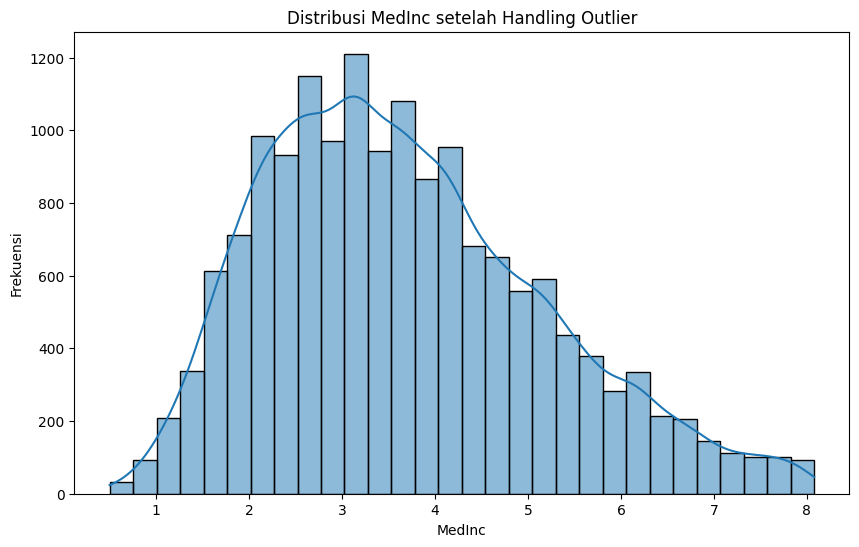

In [18]:
### Assignment 1.b Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
### Dan cek distribusinya kembali
# pilih kolom
kolom = 'MedInc'
# Hitung Q1, Q3, dan IQR
Q1 = train_clfr[kolom].quantile(0.25)
Q3 = train_clfr[kolom].quantile(0.75)
IQR = Q3 - Q1
# Tentukan batas bawah dan batas atas
batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR
# Filter data untuk menghapus outlier
train_clfr_no_outliers = train_clfr[(train_clfr[kolom] >= batas_bawah) & (train_clfr[kolom] <= batas_atas)]
# Cek distribusi kembali setelah handling outlier
plt.figure(figsize=(10, 6))
sns.histplot(train_clfr_no_outliers[kolom], bins=30, kde=True)
plt.title(f'Distribusi {kolom} setelah Handling Outlier')
plt.xlabel(kolom)
plt.ylabel('Frekuensi')
plt.show()

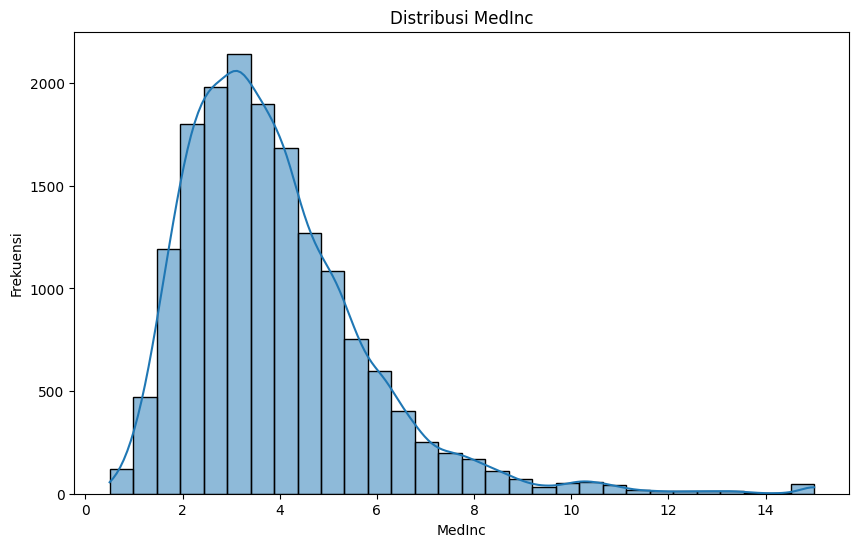

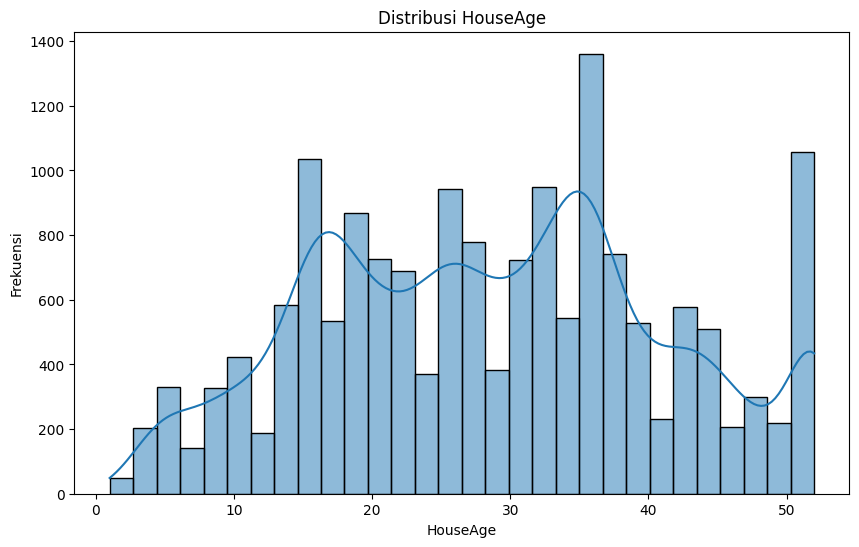

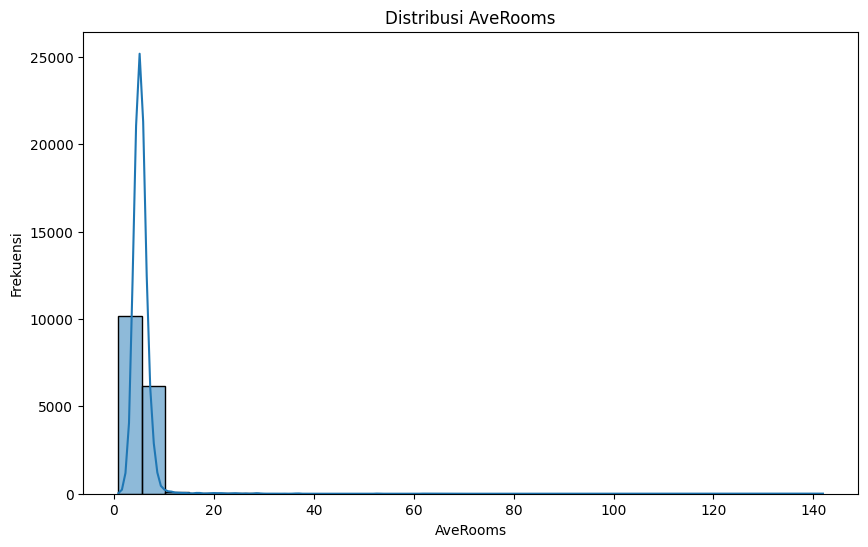

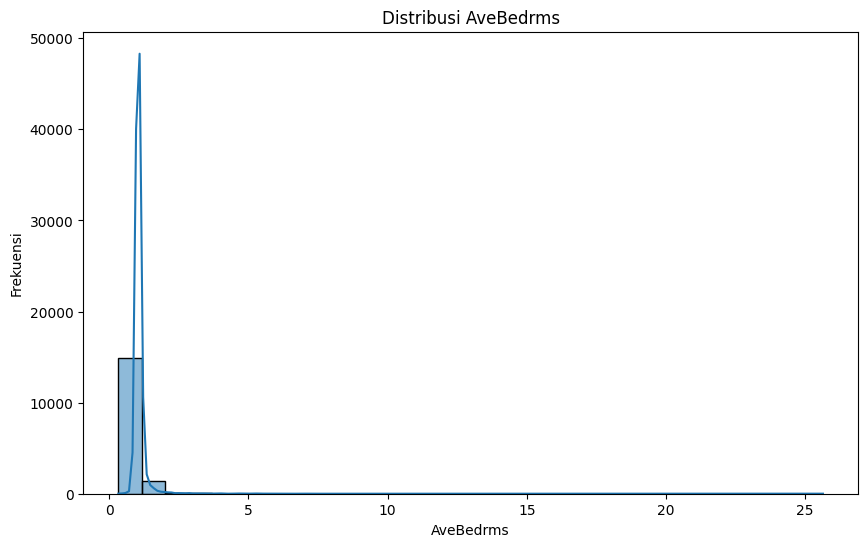

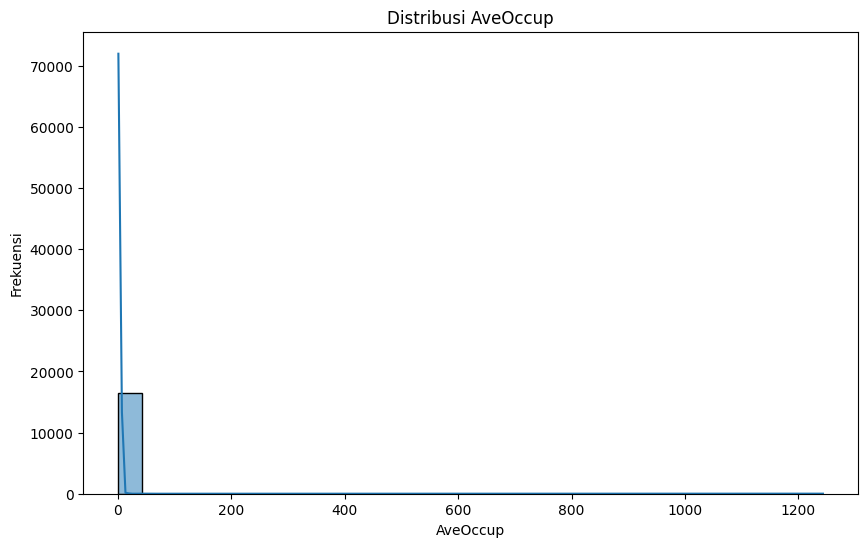

In [7]:
# Melakukan loop untuk mengecek distribusi tiap kolom
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']
for kolom in kolom_kolom:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_clfr[kolom], bins=30, kde=True)
    plt.title(f'Distribusi {kolom}')
    plt.xlabel(kolom)
    plt.ylabel('Frekuensi')
    plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [19]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [5]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu
train_clfr, test_clfr = train_test_split(df_california, test_size = 0.2, random_state=42)
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [ ]:
#Tulis jawaban missing value handling kolom Headquarters disini

#1. dari data company.csv, tidak ada missing value dalam bentuk NaN
#string kosong ('') atau nonee pada kolom headquarters.

# namun, terdapat 31 data dengan nilai "-1" yang berfungsi sebagai placeholder atau kode untuk data yang hilang/tidak tersedia
# Persentasenya adalah 31/672= 4.61%

#2 karena persentase hanya 4.61%, tidak perlu melakukan drop kolom headquarters
# Kolom masih memiliki ~95.39% data yang berguna sehingga layak dipertahankan degan penganan yang sesuai

#3. Karena tidak di-drop, lakukan handling pada nilai "-1."
#kolom headquarters bersifat kategorikal, sehingga cara paling menggunakan modus(nilai yang paling sering muncul).
   


In [9]:
import pandas as pd
df = pd.read_csv('company.csv')

num_dash = (df['Headquarters'] == '-1').sum()
percent = (num_dash / len(df)) * 100
print(f"Jumlah data dengan nilai '-1': {num_dash} ({percent:.2f}%)")

modus_hq = df['Headquarters'].mode()[0]
df['Headquarters'] = df['Headquarters'].replace('-1', modus_hq)

Jumlah data dengan nilai '-1': 31 (4.61%)


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [10]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')

In [11]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df_churn = pd.read_csv('TelcoCustomerChurn.csv')

df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')

df_churn = df_churn.drop('customerID', axis=1)

df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(0)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

label_enc = LabelEncoder()
for col in binary_cols:
    df_churn[col] = label_enc.fit_transform(df_churn[col])

df_churn = pd.get_dummies(df_churn, columns=['gender'], drop_first=True)

ohe_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]
df_churn = pd.get_dummies(df_churn, columns=ohe_cols, drop_first=True)

mean_contract = df_churn.groupby('Contract')['Churn'].mean()
df_churn['Contract_mean_enc'] = df_churn['Contract'].map(mean_contract)

df_churn = df_churn.drop('Contract', axis=1)

print("Shape setelah encoding:", df_churn.shape)
print(df_churn.head())

Shape setelah encoding: (7043, 30)
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  TotalCharges  Churn  gender_Male  \
0           29.85         29.85      0        False   
1           56.95       1889.50      0         True   
2           53.85        108.15      1         True   
3           42.30       1840.75      0         True   
4           70.70        151.65      1        False   

   MultipleLines_No phone service  MultipleLines_Yes  \
0                            True              False   
1                           False  

## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [14]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

df_churn = pd.read_csv('TelcoCustomerChurn.csv')

df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'], errors='coerce')

df_churn = df_churn.drop('customerID', axis=1)

df_churn['TotalCharges'] = df_churn['TotalCharges'].fillna(0)

binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Churn']

label_enc = LabelEncoder()
for col in binary_cols:
    df_churn[col] = label_enc.fit_transform(df_churn[col])

df_churn = pd.get_dummies(df_churn, columns=['gender'], drop_first=True)

ohe_cols = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'PaymentMethod'
]
df_churn = pd.get_dummies(df_churn, columns=ohe_cols, drop_first=True)

mean_contract = df_churn.groupby('Contract')['Churn'].mean()
df_churn['Contract_mean_enc'] = df_churn['Contract'].map(mean_contract)

df_churn = df_churn.drop('Contract', axis=1)

print("Shape setelah encoding:", df_churn.shape)
print(df_churn.head())


Shape setelah encoding: (7043, 30)
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  TotalCharges  Churn  gender_Male  \
0           29.85         29.85      0        False   
1           56.95       1889.50      0         True   
2           53.85        108.15      1         True   
3           42.30       1840.75      0         True   
4           70.70        151.65      1        False   

   MultipleLines_No phone service  MultipleLines_Yes  \
0                            True              False   
1                           False  

## Selesai :)